**Oreum Industries Internal Project, 2021Q1**

---

### Oreum Copula Modelling `oreum_copula`

# 10_ModelA

Build & test Model A:
+ [x] Create simple synthetic data
+ [x] Construct model with simple marginals, Gaussian copula
+ [x] Test sampling and parameter recovery


## Contents

+ [Setup](#Setup)

+ [1. Generate & Prepare Synthetic Data](#1.-Generate-&-Prepare-Synthetic-Data)

+ [2. Build Model & Evaluate Priors](#2.-Build-Model-&-Evaluate-Priors)

+ [3. Sample Model & View Diagnostics](#3.-Sample-Model-&-View-Diagnostics)

+ [4. Evaluate Posterior Distributions](#4.-Evaluate-Posterior-Distributions)


---

# Setup

## Imports

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import patsy as pt
import pymc3 as pm
import seaborn as sns
import warnings

from oreum_core import curate, eda
from oreum_core import model as mt # aka "model_tools": to disambiguate from src.model
from scipy import stats, special

# autoreload src while under development
%load_ext autoreload
%autoreload 2
from src import model

##### Notebook config

In [2]:
%config InlineBackend.figure_format = 'retina'
sns.set(style='darkgrid', palette='muted', context='notebook')
plt.rcParams['figure.figsize'] = 14, 2
RANDOM_SEED = 42
RNG = np.random.default_rng(seed=RANDOM_SEED)

## Local Functions and Global Vars

In [3]:
DIR_DATA_MODEL = ['data', 'mdla']
DIR_PLOTS = ['plots']
CLIP_VAL = 1e-12
# ppq_model = curate.PandasParquetIO(DIR_DATA_MODEL)
# txtio = curate.SimpleStringIO(DIR_DATA_MODEL)

## Data Connections

In [4]:
# None

---

---

# 1. Generate & Prepare Synthetic Data

Marginals & Copula w/out Observational Parameters

## 1.1 Create observed marginals using a "forward-pass": start at copula -> transform to marginals

This follows the same process as in [01_Background_Copula.ipynb](01_Background_Copula.ipynb). Note the parameter values for the marginals: we will attempt to recover these using our model.

### 1.1.1 Generate random samples from multivariate normal with known covariance

**NOTE:**

+ Lazily choose to set off-diagonal covariance to 1: i.e. we create the data using a correlation matrix, rather than a covariance matrix
+ We will still use a proper covariance matric in the estimation, but the off-diagonal fits should get very close to 1
+ Set a high correlation for ease of viewing

In [5]:
NOBS = 100
r = -0.8
TRUE_COV = np.array([[1., r], [r, 1.]])
mvnorm = stats.multivariate_normal(mean=np.zeros(2), cov=TRUE_COV) 
df = pd.DataFrame(mvnorm.rvs(NOBS, random_state=RANDOM_SEED), columns=['mvn1', 'mvn2'])

### 1.1.2 Transform Normal marginals to Uniform [0, 1] by passing through the Normal CDF 

In [6]:
df = pd.concat([df, pd.DataFrame(stats.norm.cdf(df[['mvn1', 'mvn2']]), 
                                 columns=['u1', 'u2'])], axis=1)

### 1.1.3 Transform the Uniform marginals to our marginals of interest using their Inverse CDFs

In [7]:
M1_MU = 1
M1_SIGMA = 0.3

M2_MU = 0.3
M2_SIGMA = 1.4

m1_dist = stats.lognorm(scale=np.exp(M1_MU), s=M1_SIGMA)
m2_dist = stats.lognorm(scale=np.exp(M2_MU), s=M2_SIGMA)

# Percent Point Function (PPF) aka Quantile Function aka Inverse CDF
df['m1'] = m1_dist.ppf(df['u1'])  
df['m2'] = m2_dist.ppf(df['u2'])

##### Plot

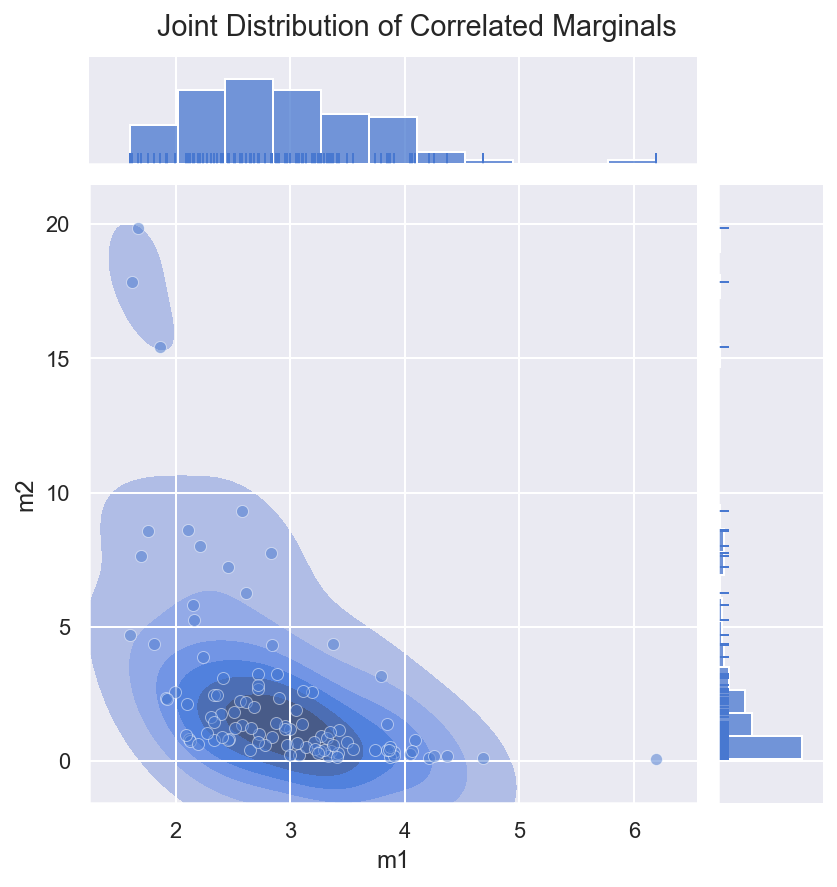

In [8]:
kde_kws = dict(zorder=0, levels=7, cut=1)
sctr_kws = dict(zorder=1, alpha=0.5)
g = sns.JointGrid(x='m1', y='m2', data=df)
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_joint(sns.scatterplot, **sctr_kws)
g.plot_marginals(sns.histplot)
g.plot_marginals(sns.rugplot, height=0.1)
_ = g.fig.suptitle('Joint Distribution of Correlated Marginals', y=1.02)

## 1.2 Transform observations for linear sub-models

Normally, we would use `patsy` to transform the "raw" (synthetic) data created above into two separate design-matrices (for marginal 1 and marginal 2) each according to a linear model. This is total overkill here, so we'll keep life much simpler.

We have no features for `m1` and `m2`, so the linear sub-models have to be intercept-only. Here we must also forget anything we know about the construction of the synthetic data. This is all we have:

In [9]:
df[['m1', 'm2']].describe()

,m1,m2
count,100.000000,100.000000
mean,2.913279,2.426713
std,0.768937,3.477386
min,1.596425,0.059871
25%,2.353768,0.507964
50%,2.839826,1.175023
75%,3.348867,2.588860
max,6.193901,19.842290


In [10]:
dfx_m1 = df[['m1']].copy()
dfx_m1['intercept'] = 1
dfx_m1.head(3)

,m1,intercept
0,2.329179,1
1,2.612093,1
2,2.841776,1
3,1.865172,1
4,3.270970,1


In [11]:
dfx_m2 = df[['m2']].copy()
dfx_m2['intercept'] = 1
dfx_m2.head(3)

,m2,intercept
0,2.455921,1
1,6.262039,1
2,0.891679,1
3,15.443679,1
4,0.920044,1


---

---

# 2. Build Model & Evaluate Priors

Uses a backward pass to infer covariance etc. 

Unfortunately not possible to sample prior or posterior predictive because it's not a forward pass. But it samples, and is a good option for inference and manual PPC.

This is influenced by a working notebook from [Junpenlao](https://github.com/junpenglao/Planet_Sakaar_Data_Science/blob/master/WIP/vector_transformation_copulas.ipynb)

See also:
+ Twiecki's blogpost [An intuitive, visual guide to copulas](https://twiecki.io/blog/2018/05/03/copulas/)
+ A post on [pymc3 Discourse](https://discourse.pymc.io/t/help-with-copula-model-with-gamma-marginals/2030)


## 2.0 Model Spec

### Estimate Marginals

#### M1
\begin{align}
    \mu_{m1} &\sim \text{Normal}(\mu=\beta^{T}\vec{x}_{y}^{j1}, \sigma) \\
    \sigma_{m1} &\sim \text{InverseGamma}(\alpha, \beta) \\
    \mathfrak{m1}_{y} &\sim \text{Lognormal}(\mu=\mu_{m1}, \sigma=\sigma_{m1})
\end{align}


#### M2
\begin{align}
    \mu_{m2} &\sim \text{Normal}(\mu=\beta^{T}\vec{x}_{y}^{j2}, \sigma) \\
    \sigma_{m2} &\sim \text{InverseGamma}(\alpha, \beta) \\
    \mathfrak{m2}_{y} &\sim \text{Lognormal}(\mu=\mu_{m2}, \sigma=\sigma_{m2})
\end{align}

Where:
+ Features in $\vec{x}^{j1}$ and $\vec{x}^{j2}$ are each chosen from the full set of features $j \in m$
+ In our synthetic data here, we have no features $m$ (!), so $j1$ and $j2$ are both intercept-only
+ Note we use the same distribution family for each marginal, because we want to keep this example simple


### Estimate Copula

1. Create covariance:

\begin{align}
    L &\sim \text{LKJCholesky}(2), \; R \sim \text{LKJCorr}(2) \\
    \sigma &\sim \text{InverseGamma}(\alpha, \beta) \\
    \Sigma &\sim LL^{T} = diag(\sigma) * R * diag(\sigma)
\end{align}

2. Transform marginals via their CDFs:
\begin{align}
    \mathbf{m1u}_{y} &= \mathfrak{m1}_{y}\Phi(\mathbf{m1}_{y}) \\
    \mathbf{m2u}_{y} &= \mathfrak{m2}_{y}\Phi(\mathbf{m2}_{y})
\end{align}


3. Transform the uniform marginals via a Normal InvCDF:
\begin{align}
    (\mathbf{m1n}, \mathbf{m2n})_{y} &= \text{MvNormal}(\mu=0, \sigma=1)\Phi^{-1}([\mathbf{m1u}_{y}, \mathbf{m2u}_{y}])
\end{align}


4. Evaluate likelihood at the copula:

\begin{align}
    copula &\sim \text{MvNormal}(\mu=0, \Sigma, observed=(\mathbf{m1n}, \mathbf{m2n})_{y}
\end{align}


---

## 2.1 Build Model Object

**NOTE:** Model imported from `src.model.py` where it is fully defined

In [12]:
mdl = model.ModelA(obs_m1=dfx_m1, obs_m2=dfx_m2)
mdl.build()

Built model mdla


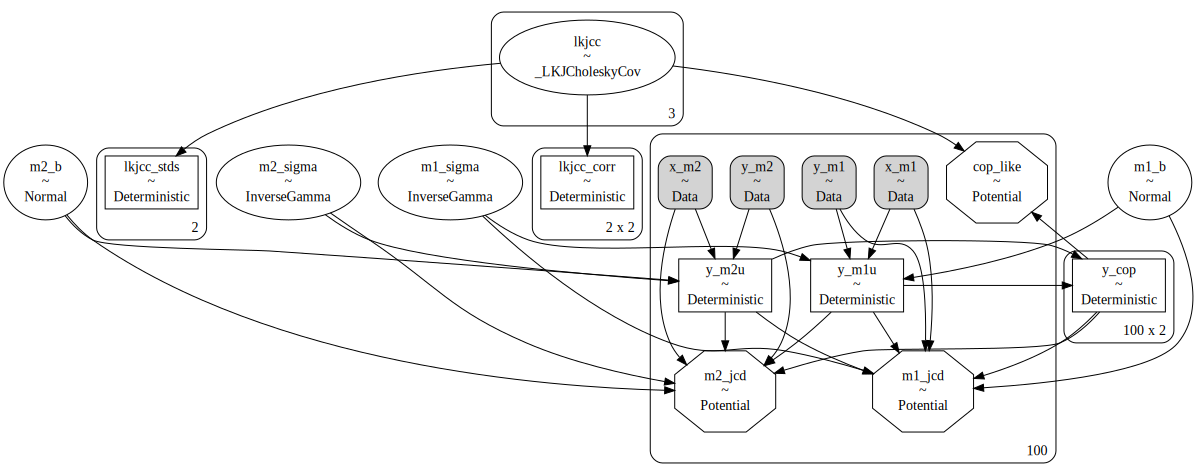

In [13]:
display(pm.model_graph.model_to_graphviz(mdl.model))

---

## 2.2 Evaluate Prior Predictive on Parameters

In [14]:
mdl.sample_prior_predictive()
mdl.trace_prior.keys()

dict_keys(['y_m2u', 'm1_b', 'y_cop', 'lkjcc_corr', 'm1_sigma', 'm2_jcd', 'y_m1u', 'm2_sigma', 'lkjcc_stds', 'm2_b', 'cop_like', 'm1_jcd', 'm2_sigma_log__', 'lkjcc', 'lkjcc_cholesky-cov-packed__', 'm1_sigma_log__'])

In [15]:
azid_p = mt.create_azid(model=mdl.model, save=False, prior=mdl.trace_prior)
azid_p

Inference data with groups:
	> prior

### 2.2.1 Prior Pred: Hyperpriors on Marginals

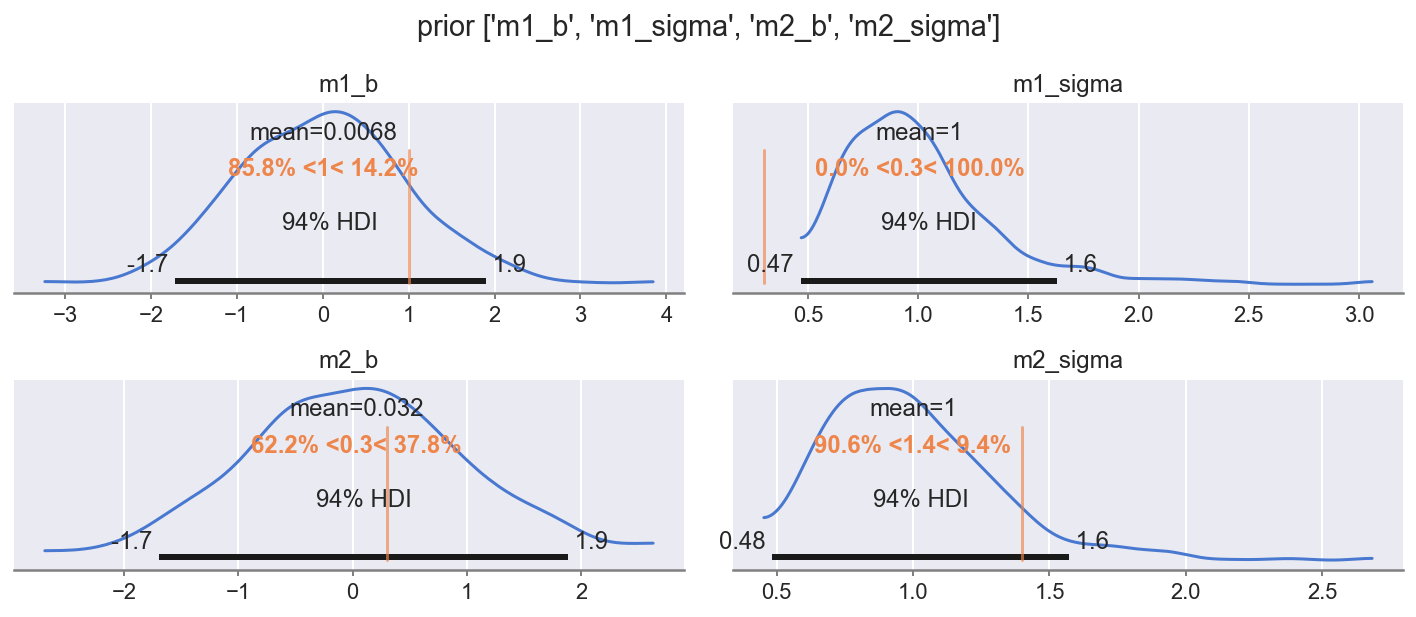

In [36]:
rvs = ['m1_b', 'm1_sigma', 'm2_b', 'm2_sigma']
if set(rvs).issubset(set(mdl.model.named_vars.keys())):
    mt.facetplot_azid_dist(azid_p, rvs, m=2, rvs_hack=0, group='prior',
                      ref_val = [M1_MU, M1_SIGMA, M2_MU, M2_SIGMA])

### 2.2.2 Prior Pred: LKJCholeskyCov (and stds)

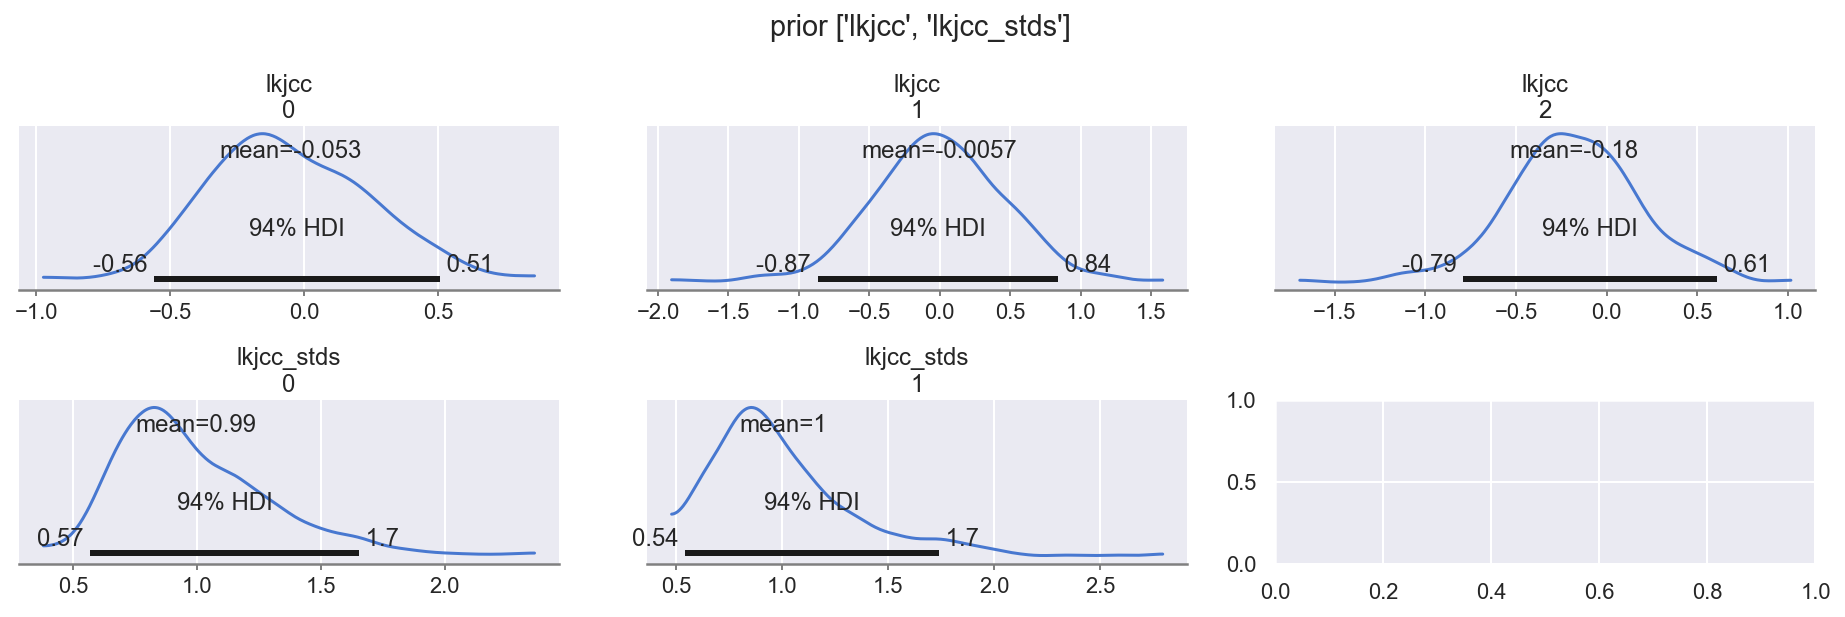

In [17]:
rvs = ['lkjcc', 'lkjcc_stds']
mt.facetplot_azid_dist(azid_p, rvs, group='prior')

### 2.2.3 Prior Pred: LKJCholeskyCov Correlation Matrix

**Note for plotting:** Need minor hack to diags to jitter them away from 1, otherwise get failure to estimate bandwidth for the density plot

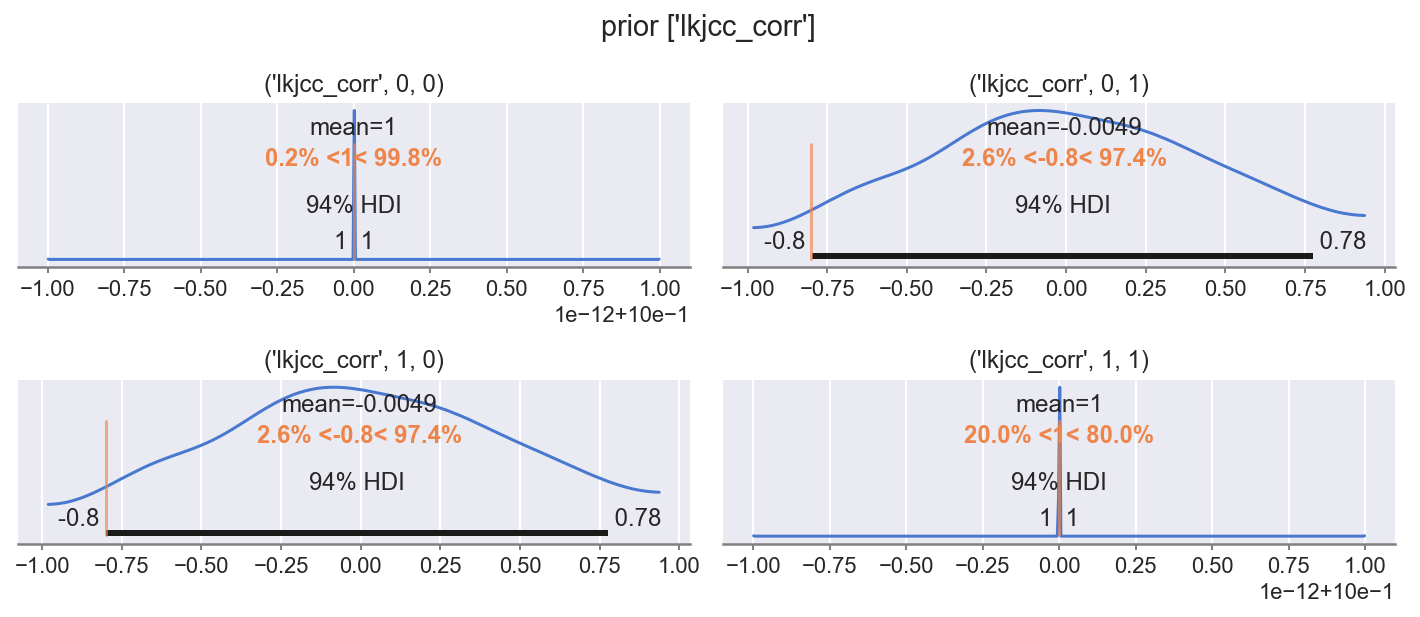

In [18]:
df_lkjcc_corr = azid_p.prior['lkjcc_corr'].to_dataframe().unstack().unstack()
df_lkjcc_corr.columns = df_lkjcc_corr.columns.to_flat_index()
df_lkjcc_corr
if sum(df_lkjcc_corr.iloc[:, 0]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 0] += -CLIP_VAL
    df_lkjcc_corr.iloc[-2, 0] += CLIP_VAL
if sum(df_lkjcc_corr.iloc[:, 3]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 3] += -CLIP_VAL
    df_lkjcc_corr.iloc[-2, 3] += CLIP_VAL
rvs = ['lkjcc_corr']
mt.facetplot_df_dist(df_lkjcc_corr, rvs, m=2, rvs_hack=3, ref_val=TRUE_COV.flatten(), title='prior')

### 2.2.4 Prior Pred: Freq Obs U, Sev Obs U (freq and sev dists post dist.CDF to uniform)

In particular, looking for infs post-processing

In [19]:
dfp_y_m1m2u = pd.DataFrame({
            'm1u' :np.nanmean(azid_p.prior.y_m1u.values[0], axis=0), 
            'm2u': np.nanmean(azid_p.prior.y_m2u.values[0], axis=0)})
dfp_y_m1m2u.describe()

,m1u,m2u
count,100.000000,100.000000
mean,0.768364,0.527685
std,0.054563,0.269992
min,0.634270,0.022619
25%,0.732355,0.309536
50%,0.773939,0.540764
75%,0.806915,0.744209
max,0.900376,0.979074


### 2.2.5 Prior Pred: Copula Obs (freq and sev dists post dist.CDF to uniform and post normal.invCDF to Normal)

In [20]:
dfp_copula_obs = pd.DataFrame(np.nanmean(azid_p.prior.y_cop.values[0], axis=0), columns=['c1', 'c2'])
dfp_copula_obs.describe()

,c1,c2
count,100.000000,100.000000
mean,1.135233,0.144745
std,0.283215,1.351312
min,0.512819,-3.110571
25%,0.937992,-0.776312
50%,1.143583,0.144311
75%,1.324147,1.009845
max,1.997585,3.240751


#### Mean across samples

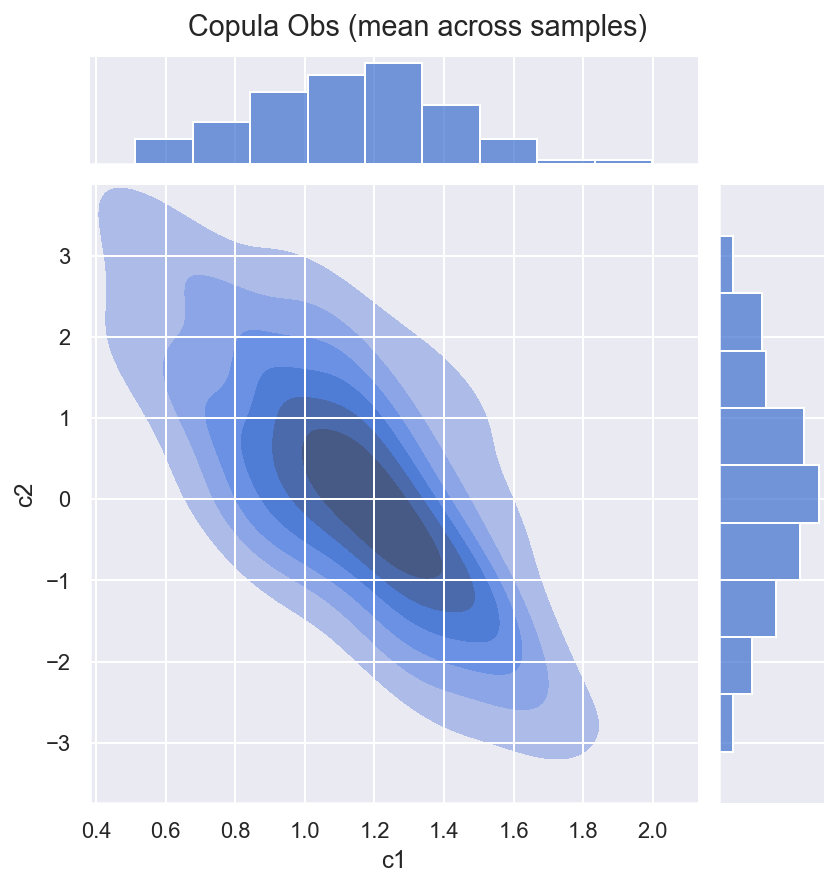

In [21]:
SKIP = 1
g = sns.JointGrid(x='c1', y='c2', data=dfp_copula_obs.iloc[::SKIP])
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Copula Obs (mean across samples)', y=1.02)

#### Percentiles across samples (how wild does this get?)

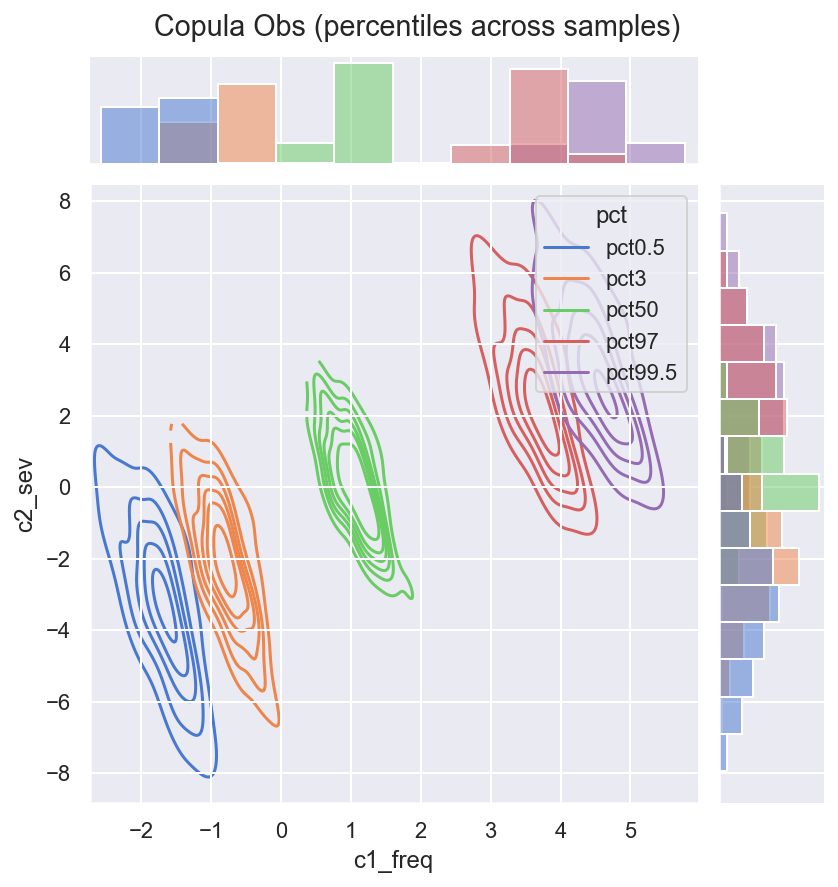

In [22]:
ps = [0.5, 3, 50, 97, 99.5]
dfp_copula_obs_pct = pd.DataFrame(np.percentile(azid_p.prior.y_cop.values[0], ps, axis=0
                                               ).reshape(len(ps)*NOBS, 2),
                                  columns=['c1_freq', 'c2_sev'])
dfp_copula_obs_pct['pct'] = np.repeat([f'pct{p}'  for p in ps], NOBS)
g = sns.JointGrid(x='c1_freq', y='c2_sev', hue='pct', data=dfp_copula_obs_pct.iloc[::SKIP])
g.plot_joint(sns.kdeplot, **kde_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Copula Obs (percentiles across samples)', y=1.02)

---

---

# 3. Sample Model & View Diagnostics

## 3.1 Sample Posterior

In [23]:
mdl.sample()
azid_pt = mt.create_azid(model=mdl.model, save=True, dir_traces=DIR_DATA_MODEL, fn='mdla_azid',
                         prior=mdl.trace_prior, trace=mdl.trace)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lkjcc, m2_sigma, m2_b, m1_sigma, m1_b]


INFO (theano.gof.compilelock): Waiting for existing lock by process '30308' (I am process '30341')
INFO (theano.gof.compilelock): To manually release the lock, delete /Users/jon/.theano/compiledir_macOS-10.15.7-x86_64-i386-64bit-i386-3.9.6-64/lock_dir
INFO (theano.gof.compilelock): Waiting for existing lock by process '30341' (I am process '30308')
INFO (theano.gof.compilelock): To manually release the lock, delete /Users/jon/.theano/compiledir_macOS-10.15.7-x86_64-i386-64bit-i386-3.9.6-64/lock_dir
Sampling 4 chains for 2_000 tune and 500 draw iterations (8_000 + 2_000 draws total) took 71 seconds.


## 3.2 View Diagnostics

### 3.2.1 Posterior Traceplots

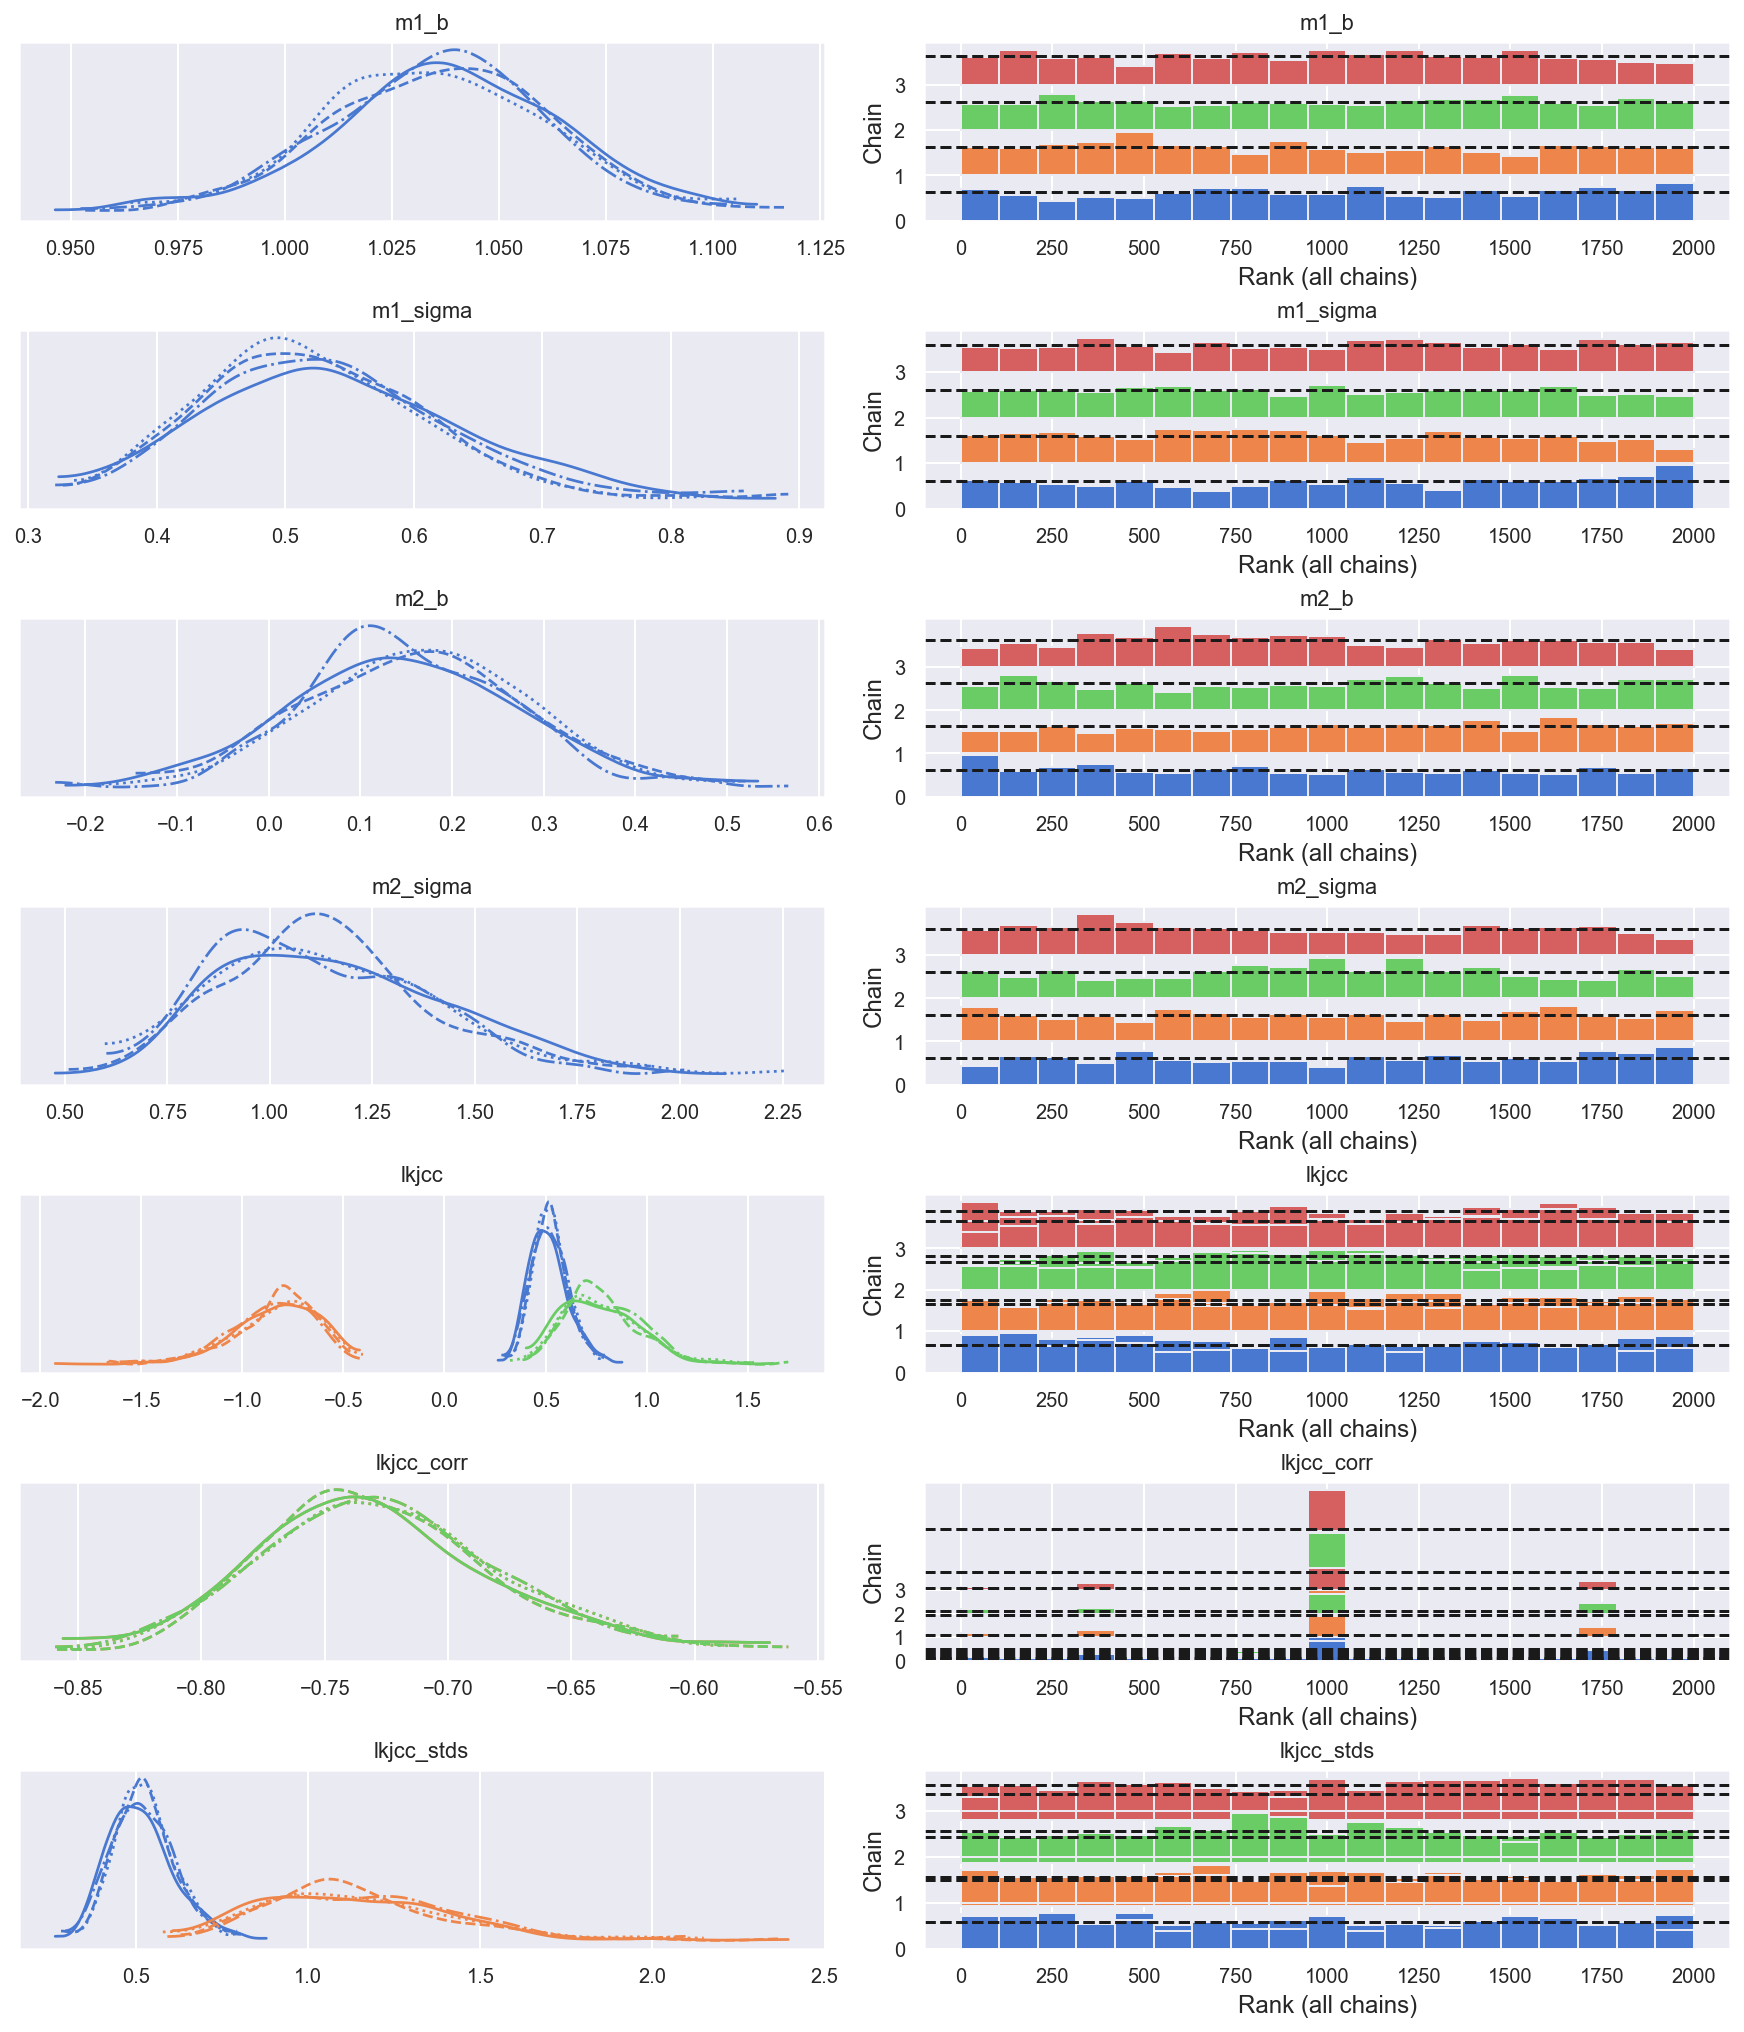

In [29]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _ = az.plot_trace(azid_pt, var_names=mdl.rvs_for_posterior_plots, 
                      compact=True, combined=False, kind="rank_bars")

**Observe:**
    
+ Traces appear reasonably well-mixed, no divergences
+ Posterior distributions reasonably central

### 3.2.2 Summary

In [30]:
eda.display_fw(az.summary(azid_pt, var_names=mdl.rvs_for_posterior_plots), max_rows=150)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_mean,ess_sd,ess_bulk,ess_tail,r_hat
m1_b,1.036,0.026,0.989,1.086,0.001,0.000,1368.0,1368.0,1362.0,1083.0,1.0
m1_sigma,0.530,0.094,0.361,0.703,0.003,0.002,760.0,727.0,791.0,802.0,1.0
m2_b,0.158,0.121,-0.069,0.382,0.003,0.002,1378.0,1323.0,1375.0,1360.0,1.0
m2_sigma,1.147,0.275,0.696,1.680,0.010,0.007,802.0,802.0,806.0,940.0,1.0
lkjcc[0],0.521,0.090,0.368,0.707,0.003,0.002,841.0,841.0,826.0,870.0,1.0
lkjcc[1],-0.838,0.214,-1.219,-0.469,0.007,0.005,842.0,832.0,853.0,1014.0,1.0
lkjcc[2],0.783,0.194,0.459,1.116,0.007,0.005,856.0,856.0,843.0,1005.0,1.0
"lkjcc_corr[0,0]",1.000,0.000,1.000,1.000,0.000,0.000,2000.0,2000.0,2000.0,2000.0,NaN
"lkjcc_corr[0,1]",-0.728,0.048,-0.816,-0.637,0.001,0.001,2249.0,2249.0,2278.0,1396.0,1.0
"lkjcc_corr[1,0]",-0.728,0.048,-0.816,-0.637,0.001,0.001,2249.0,2249.0,2278.0,1396.0,1.0


### 3.2.3 Energy

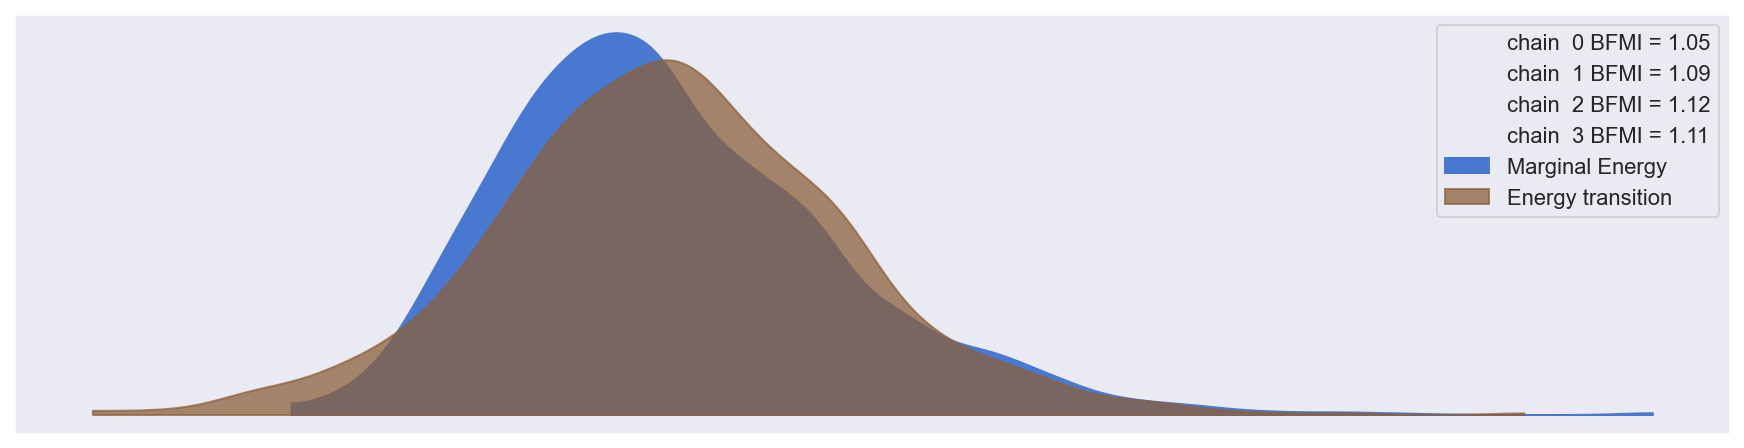

In [31]:
_ = az.plot_energy(azid_pt, figsize=(12, 3))

**Observe:**

+ BFMI above 0.3, so [apparently reasonable](https://arxiv.org/pdf/1701.02434.pdf)
+ A little messy though, not symmetric

---

---

# 4. Evaluate Posterior Distributions

### 2.2.1 Prior Pred: Hyperpriors on Marginals

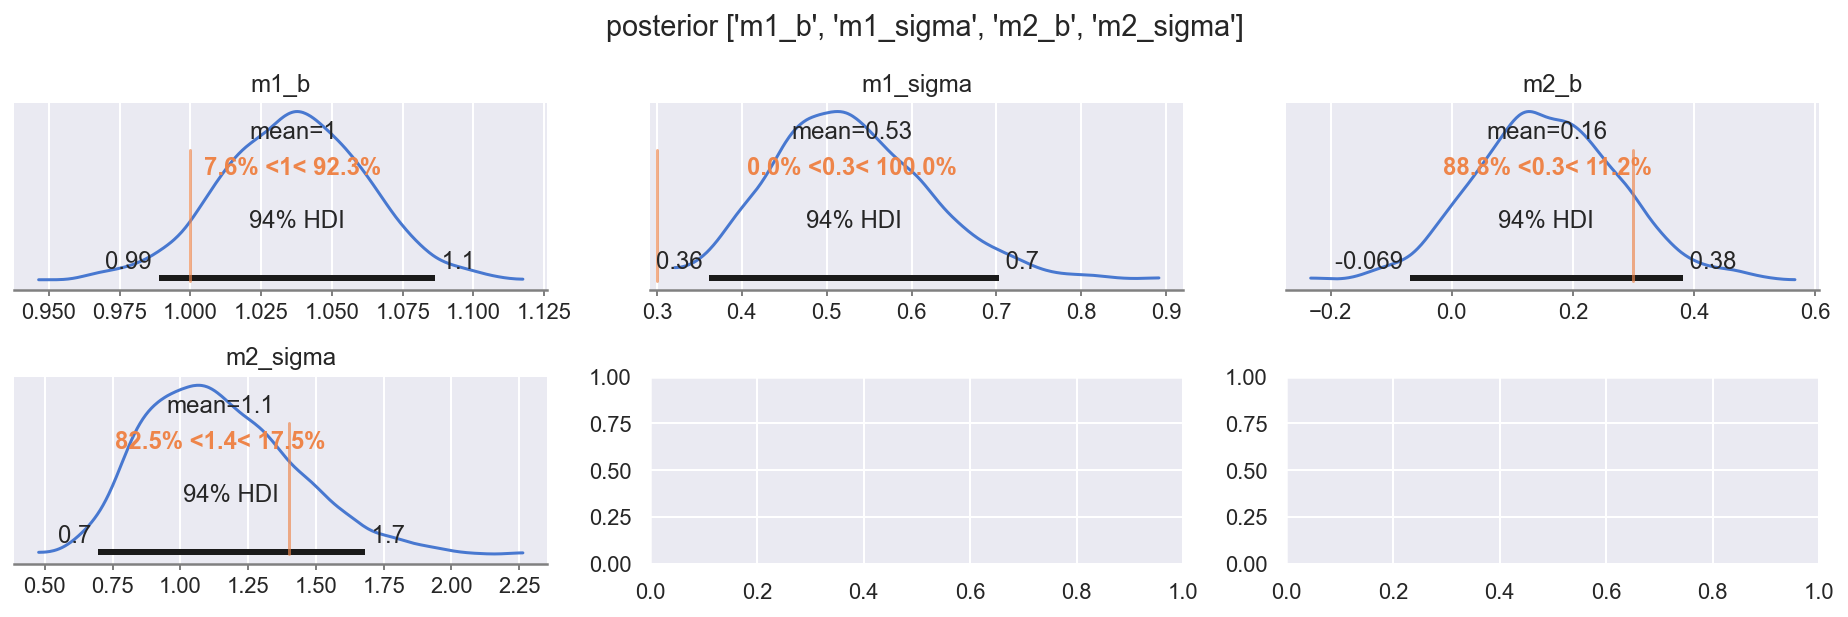

In [35]:
rvs = ['m1_b', 'm1_sigma', 'm2_b', 'm2_sigma']
if set(rvs).issubset(set(mdl.model.named_vars.keys())):
    mt.facetplot_azid_dist(azid_pt, rvs, rvs_hack=0, group='posterior',
                          ref_val = [M1_MU, M1_SIGMA, M2_MU, M2_SIGMA])

### 2.2.2 Prior Pred: LKJCholeskyCov (and stds)

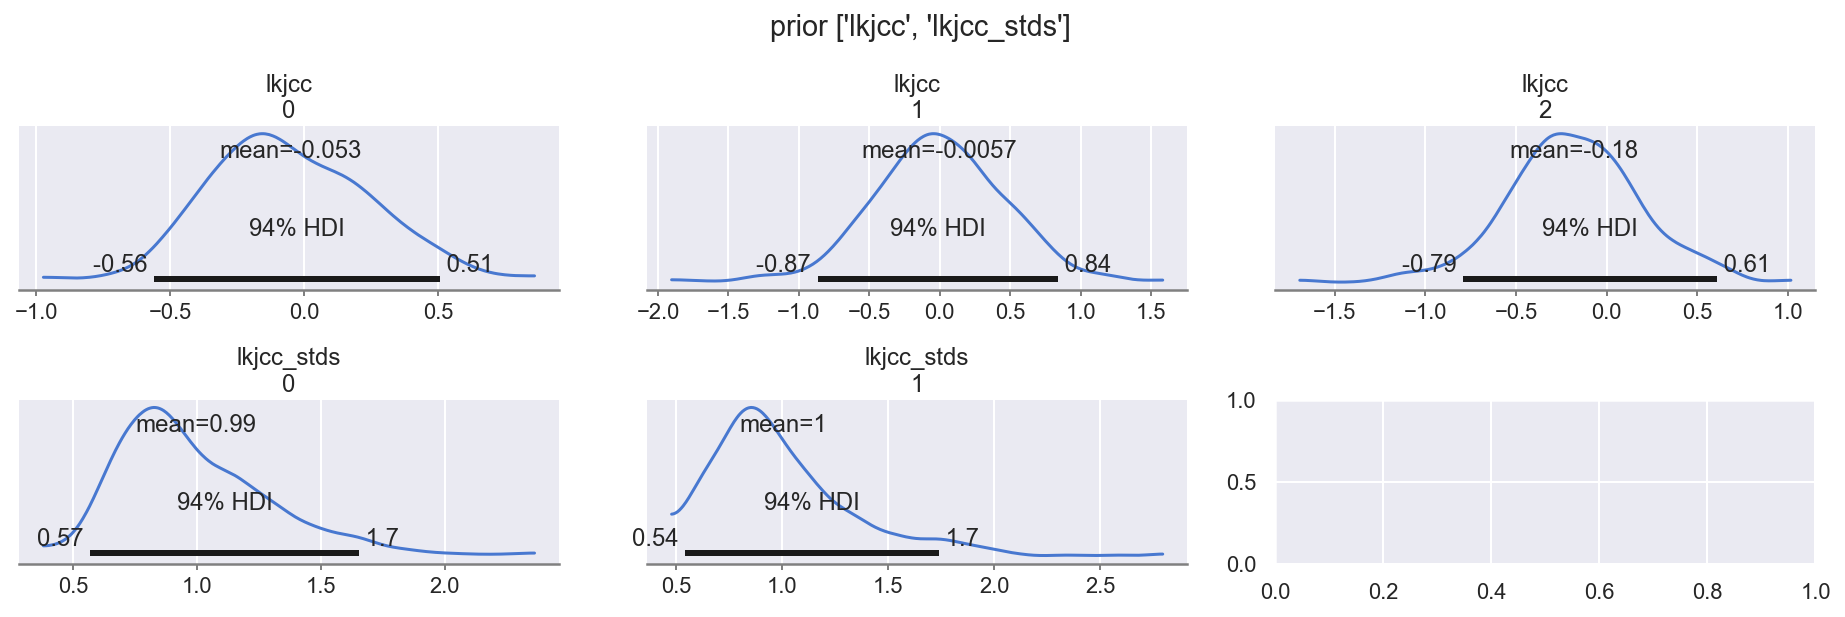

In [17]:
rvs = ['lkjcc', 'lkjcc_stds']
mt.facetplot_azid_dist(azid_p, rvs, group='prior')

### 2.2.3 Prior Pred: LKJCholeskyCov Correlation Matrix

**Note for plotting:** Need minor hack to diags to jitter them away from 1, otherwise get failure to estimate bandwidth for the density plot

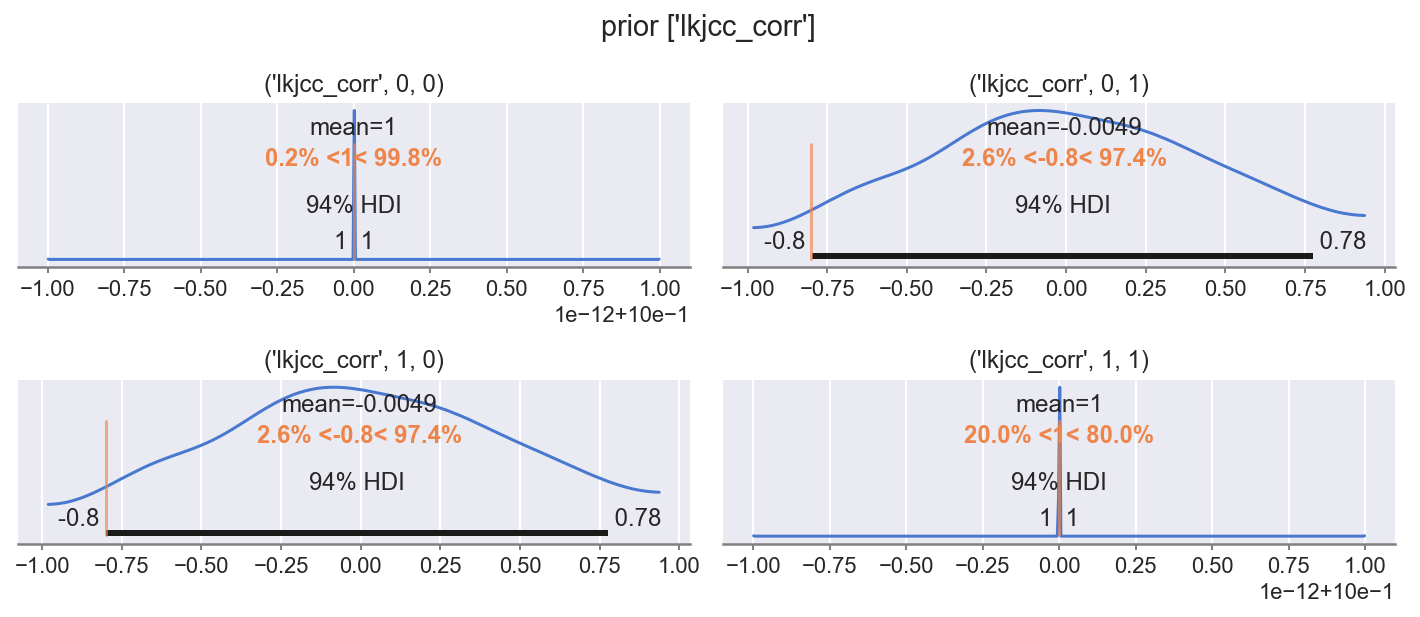

In [18]:
df_lkjcc_corr = azid_p.prior['lkjcc_corr'].to_dataframe().unstack().unstack()
df_lkjcc_corr.columns = df_lkjcc_corr.columns.to_flat_index()
df_lkjcc_corr
if sum(df_lkjcc_corr.iloc[:, 0]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 0] += -CLIP_VAL
    df_lkjcc_corr.iloc[-2, 0] += CLIP_VAL
if sum(df_lkjcc_corr.iloc[:, 3]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 3] += -CLIP_VAL
    df_lkjcc_corr.iloc[-2, 3] += CLIP_VAL
rvs = ['lkjcc_corr']
mt.facetplot_df_dist(df_lkjcc_corr, rvs, m=2, rvs_hack=3, ref_val=TRUE_COV.flatten(), title='prior')

### 2.2.4 Prior Pred: Freq Obs U, Sev Obs U (freq and sev dists post dist.CDF to uniform)

In particular, looking for infs post-processing

In [19]:
dfp_y_m1m2u = pd.DataFrame({
            'm1u' :np.nanmean(azid_p.prior.y_m1u.values[0], axis=0), 
            'm2u': np.nanmean(azid_p.prior.y_m2u.values[0], axis=0)})
dfp_y_m1m2u.describe()

,m1u,m2u
count,100.000000,100.000000
mean,0.768364,0.527685
std,0.054563,0.269992
min,0.634270,0.022619
25%,0.732355,0.309536
50%,0.773939,0.540764
75%,0.806915,0.744209
max,0.900376,0.979074


## 2.4 Evaluate Posterior Distributions

### 2.4.1 Posterior: Hyperpriors on Marginals

In [ ]:
rvs = ['freq_mu', 'freq_sigma', 'sev_alpha', 'sev_s']
model.facetplot_azid_dist(azid_pt, rvs, rvs_hack_extra=0, group='posterior', ref_val=[FREQ_MU, FREQ_SIGMA, SEV_ALPHA, SEV_S])

### 2.4.2 Posterior: LKJCholeskyCov (and stds)

In [ ]:
rvs = ['lkjcc', 'lkjcc_stds']
model.facetplot_azid_dist(azid_pt, rvs, rvs_hack_extra=2 + 2, group='posterior')

### 2.4.3 Posterior: LKJCholeskyCov Correlation Matrix

**Note for plotting:** 
+ Need minor hack to diags to jitter them away from 1, otherwise get failure to estimate bandwidth for the density plot

In [ ]:
df_lkjcc_corr = azid_pt.posterior['lkjcc_corr'].to_dataframe().unstack().unstack()
df_lkjcc_corr.columns = df_lkjcc_corr.columns.to_flat_index()
if sum(df_lkjcc_corr.iloc[:, 0]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 0] = (1 - CLIP_VAL)
    df_lkjcc_corr.iloc[-2, 0] = (1 + CLIP_VAL)
if sum(df_lkjcc_corr.iloc[:, 3]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 3] = (1 - CLIP_VAL)
    df_lkjcc_corr.iloc[-2, 3] = (1 + CLIP_VAL)
display(eda.custom_describe(df_lkjcc_corr))
rvs = ['lkjcc_corr']
model.facetplot_df_dist(df_lkjcc_corr, rvs, rvs_hack_extra=3, ref_val=[1, R, R, 1], title='posterior')

In [ ]:
df_lkjcc_corr = azid_pt.posterior['cov'].to_dataframe().unstack().unstack()
df_lkjcc_corr.columns = df_lkjcc_corr.columns.to_flat_index()
if sum(df_lkjcc_corr.iloc[:, 0]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 0] = (1 - CLIP_VAL)
    df_lkjcc_corr.iloc[-2, 0] = (1 + CLIP_VAL)
if sum(df_lkjcc_corr.iloc[:, 3]) == len(df_lkjcc_corr):
    df_lkjcc_corr.iloc[-1, 3] = (1 - CLIP_VAL)
    df_lkjcc_corr.iloc[-2, 3] = (1 + CLIP_VAL)
display(eda.custom_describe(df_lkjcc_corr))
rvs = ['cov']
model.facetplot_df_dist(df_lkjcc_corr, rvs, rvs_hack_extra=3, ref_val=[1, R, R, 1], sharex=True, title='posterior')

### ~~~2.4.4 Posterior: Copula Raw Mu and Copula Cov Mu~~~

In [ ]:
# rvs = ['copula_raw_mu', 'copula_cov_mu']
# model.facetplot_azid_dist(azid_pt, rvs, rvs_hack_extra=1, group='posterior')

In [ ]:
# _ = az.plot_pair(azid_pt, var_names='copula_raw_mu', divergences=True, marginals=True, figsize=(5, 5))

In [ ]:
# _ = az.plot_pair(azid_pt, var_names='copula_cov_mu', divergences=True, marginals=True, figsize=(5, 5))

### 2.4.4 Posterior: Freq Obs U, Sev Obs U (freq and sev dists post dist.CDF to uniform)

In particular, looking for infs post-processing

In [ ]:
dfp_freqsev_obs_u = pd.DataFrame({'freq_obs_u' :np.nanmean(azid_pt.posterior.freq_obs_u.values.reshape(4 * 500, N_OBS), axis=0), 
                                  'sev_obs_u': np.nanmean(azid_pt.posterior.sev_obs_u.values.reshape(4 * 500, N_OBS), axis=0)})
eda.custom_describe(dfp_freqsev_obs_u)

### 2.4.5 Copula Obs summarise observations (freq and sev dists post dist.CDF to uniform and post normal.invCDF to Normal)

In [ ]:
dfp_copula_obs = pd.DataFrame(np.nanmean(azid_pt.posterior.copula_obs.values.reshape(4 * 500, N_OBS, 2), axis=0), columns=['c1_freq', 'c2_sev'])
eda.custom_describe(dfp_copula_obs)

#### Mean across samples

In [ ]:
mean = np.nanmean(azid_pt.posterior.copula_obs.values.reshape(4 * 500, N_OBS, 2), axis=0)
dfp_copula_obs = pd.DataFrame(mean, columns=['c1_freq', 'c2_sev'])
g = sns.JointGrid(x='c1_freq', y='c2_sev', data=dfp_copula_obs.iloc[::SKIP])
g.plot_joint(sns.kdeplot, **kde_kws, fill=True)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Copula Obs (mean across samples)', y=1.02)

#### Percentiles across samples (how wild does this get?)

In [ ]:
pcts = [0, 3, 50, 97, 100]
pct = np.percentile(azid_pt.posterior.copula_obs.values.reshape(4 * 500, N_OBS, 2), pcts, axis=0).reshape(len(pcts)*N_OBS, 2)
dfp_copula_obs_pct = pd.DataFrame(pct, columns=['c1_freq', 'c2_sev'])
dfp_copula_obs_pct['pct'] = np.repeat([f'pct{p}'  for p in pcts], N_OBS)
g = sns.JointGrid(x='c1_freq', y='c2_sev', hue='pct', data=dfp_copula_obs_pct.iloc[::SKIP])
g.plot_joint(sns.kdeplot, **kde_kws)
g.plot_marginals(sns.histplot)
_ = g.fig.suptitle('Copula Obs (percentiles across samples)', y=1.02)

### 2.4.6 Params of Linear model on Freq

#### Forestplot

In [ ]:
# lbls = transformer.design_info.column_names[::-1]
# ax = az.plot_forest(azid_pt, var_names='b', figsize=(15, 2+len(lbls)*0.3))
# _ = ax[0].set_yticklabels(lbls)
# _ = ax[0].axvline(0, ls='--', c='g')

#### Pairplot Posteriors

In [ ]:
# _ = az.plot_pair(azid_pt, var_names=rvs, divergences=True, marginals=True, figsize=(10, 10))

### 2.4.7 Params of Linear model on Sev

#### Forestplot

In [ ]:
# lbls = transformer.design_info.column_names[::-1]
# ax = az.plot_forest(azid_pt, var_names='b', figsize=(15, 2+len(lbls)*0.3))
# _ = ax[0].set_yticklabels(lbls)
# _ = ax[0].axvline(0, ls='--', c='g')

#### Pairplot Posteriors

In [ ]:
# _ = az.plot_pair(azid_pt, var_names=rvs, divergences=True, marginals=True, figsize=(10, 10))

## 2.5 Evaluate PPC in-sample

### ~~2.5.1 Sample PPC~~

#### **ISSUE:** Conceptually not valid to ask PPC of this backwards model: 
1. If use `method a: copula_like = pm.MvNormal(... observed=copula_obs)`, then RVs are in likelihood and `pm.sample_posterior_predictive` explicitly cannot work
2. If use `method b: evidence via fixed dist and Potential`, then `pm.sample_posterior_predictive` does actually run, but there's no nodes in `ObservedRV` so it returns an empty dict. Needs a forwards-pass model

In [ ]:
# with mdl:
#     ppc = pm.sample_posterior_predictive(trc, random_seed=RANDOM_SEED)

# azid_ptp = model.create_azid(mdl, save=False, dir_traces=DIR_TRACES, fn=MDL_NM, 
#                        prior=trc_prior, trace=trc, ppc=ppc)
# f, axs = plt.subplots(1, 1, figsize=(12, 6))
# ax0 = az.plot_ppc(azid_ptp, num_pp_samples=20, random_seed=RANDOM_SEED, kind='cumulative', ax=axs)
# _ = axs.set_xlim(0, 10)

### 2.5.2 Recreate PPC forward-pass in a separate construct, using parameter values from trace

Because the model is not (yet) parameterised per-observation, we get a fully pooled prediction that's the same for each observation, so just do once

In [ ]:
n_chains = 4
NOBS = 500
n = n_chains * NOBS

freq_mu = azid_pt.posterior['freq_mu'].values.reshape(n, )
freq_sigma = azid_pt.posterior['freq_sigma'].values.reshape(n, )
sev_alpha = azid_pt.posterior['sev_alpha'].values.reshape(n, )
sev_s = azid_pt.posterior['sev_s'].values.reshape(n, )

# mean in case of non-centered
# copula_cov_mu = azid_pt.posterior['copula_cov_mu'].values.reshape(n, 2)

# NOTE stats.multivariate_normal can't vectorize 3d
# see https://stackoverflow.com/questions/48686934/numpy-vectorization-of-multivariate-normal

# so could loop over samples (bad)
lkjcc_corr = azid_pt.posterior['lkjcc_corr'].values.reshape(n, 2, 2)
copula_rvs = np.empty((n, 2))
for j in range(n):
    copula_rvs[j] = stats.multivariate_normal(mean=np.zeros(2), cov=lkjcc_corr[j]).rvs(1)
    # copula_rvs[j] = stats.multivariate_normal(mean=copula_cov_mu[j], cov=lkjcc_corr[j]).rvs(1)

# or better (?) use stds and create 2d normal
# not confident this is doing the right thing
# lkjcc_stds = azid_pt.posterior['lkjcc_stds'].values.reshape(n, 2)
# copula_rvs = stats.norm(loc=np.zeros(2), scale=lkjcc_stds).rvs(size=(n, 2))

# invert copula samples to uniform before marginal transform
d_norm = model.NormalNumpy()  
u_margs = d_norm.cdf(copula_rvs, mu=0, sigma=1)

# create freq marginal (invert uniform copula)
d_lognorm = model.LognormalNumpy()
freq = d_lognorm.invcdf(u_margs[:, 0], mu=freq_mu, sigma=freq_sigma)

# create sev marginal (invert uniform copula)
d_invweibull = model.InverseWeibullNumpy()
sev = d_invweibull.invcdf(u_margs[:, 1], a=sev_alpha, s=sev_s)


In [ ]:
df_ppc_single_obs = pd.DataFrame({'freq': freq, 'sev': sev})
df_ppc_single_obs['eloss'] = df_ppc_single_obs[['freq', 'sev']].product(axis=1)
eda.custom_describe(df_ppc_single_obs)

In [ ]:
eda.custom_describe(df[['freq', 'sev', 'eloss']])

In [ ]:
# trim outliers to allow plotting
idx_upper = (df_ppc_single_obs <= df_ppc_single_obs.quantile(0.99)).product(axis=1) * True
idx_lower = (df_ppc_single_obs >= df_ppc_single_obs.quantile(0.01)).product(axis=1) * True
df_ppc_single_obs_plot = df_ppc_single_obs.loc[idx_lower * idx_upper == 1].copy()
display(eda.custom_describe(df_ppc_single_obs_plot))

In [ ]:
g = sns.JointGrid(x='freq', y='sev', data=df_ppc_single_obs_plot.sample(min(100, len(df_ppc_single_obs_plot))))
g.plot_joint(sns.kdeplot, **kde_kws, fill=True, color='C2')
g.plot_marginals(sns.histplot, color='C2')
_ = g.fig.suptitle('Sample PPC for a single obs', y=1.06)

gd = sns.catplot(x='eloss', data=df_ppc_single_obs_plot, kind='violin', cut=0, color='C2', height=2, aspect=5) 
_ = gd.fig.suptitle('Expected Loss per Policy per unit Exposure', y=1.02)

---

---

# Notes

In [ ]:
%load_ext watermark
%watermark -a "jonathan.sedar@oreum.io" -udtmv -iv

---
**Oreum OÜ &copy; 2021**